# Exploratory data analysis on OpenNeuro data

### Atif M. Mahmud

### Introduction

This data has been downloaded from https://openneuro.org/datasets/ds003838/versions/1.0.6

This excerpt is from the webpage:
> 
> This dataset consists of raw 64-channel EEG, cardiovascular (electrocardiography and photoplethysmography), and pupillometry data from 86 human participants during 4 minutes of eyes-closed resting and during performance of a
> classic working memory task – digit span task with serial recall. The participants either memorized (memory) or just listened to (control condition) sequences of 5, 9, or 13 digits presented auditorily with 2 second stimulus
> onset asynchrony. The dataset can be used for (1) developing algorithms for cognitive load discrimination and detection of cognitive overload; (2) studying neural (event-related potentials and brain oscillations) and
> peripheral physiological (electrocardiography, photoplethysmography, and pupillometry) signals during encoding and maintenance of each sequentially presented memory item in a fine time scale; (3) correlating cognitive load and > individual differences in working memory to neural and peripheral physiology, and studying the relationship between the physiological signals; (4) integration of the physiological findings with the vast knowledge coming from
> behavioral studies of verbal working memory in simple span paradigms.
> 
> EEG, pupillometry, ECG and photoplethysmography, and behavioral data are stored separately in corresponding folders. Each data record can consist of four data folders:  
> - beh - behavioral data: correctness of the recall in the memory trials
> - ecg - electrocardiography (ECG)
> - photoplethysmography (PPG) data
> - eeg - EEG data
> - pupil - pupillometry and eye-tracking data
> 
> Some of the participants had some physiological data missing: sub-017, sub-094 have no pupillometry data sub-017, sub-037, sub-066 have no ECG and PPG data sub-013, sub-014, sub-015, sub-016, sub-017, sub-018, sub-019,
> sub-020, sub-021, sub-022, sub-023, sub-024, sub-025, sub-026, sub-027, sub-028, sub-029, sub-030, sub-031, sub-037, sub-066 have no EEG data

In [3]:
import mne
import pandas as pd
import csv
import matplotlib.pyplot as plt
import warnings
import os
import numpy as np
from mne_icalabel import label_components
from IPython.display import display

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=UserWarning, module="pymatreader")

# Our analysis

There are 86 participants. For simplicity we will start EDA on a subset of the participants - 20 participants. We won't use the following because they have missing data.  
- sub-013 to sub-031
- sub-037
- sub-066
- sub-094

### We will use participants 40-59 for our analysis

### We will start by exploring the individual data of participant 40

In [5]:
# The EEG data is in the `_eeg.set` files
# %matplotlib qt

raw_sub40_task = mne.io.read_raw_eeglab("data/sub-040/eeg/sub-040_task-memory_eeg.set", preload=True)
print(f"The shape of the date is {raw_sub40_task.get_data().shape}")
print(f"The channel names are: {raw_sub40_task.ch_names}")

# raw_sub40_task.plot()
# plt.show()

The shape of the date is (63, 7176340)
The channel names are: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']


From participant 40, we see that we are able to load the EEG data using `mne` and `pymatreader`. This is a 64-channel EEG, so we have 63-channels of data since one of the channels is a reference and the other values are recorded in reference to that.

## EEG Analysis

### Load, filter, and re-reference data

In [ ]:
participants = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
print(f"N =  {len(participants)}")

cache_dir = "data/filtered-referenced-eeg"
os.makedirs(cache_dir, exist_ok=True)

for participant in participants:
    cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"

    if os.path.exists(cached_file):
        print("File exists!")
    else:
        # Cached, pre-processed file not found: load raw file
        file = f"data/sub-0{participant}/eeg/sub-0{participant}_task-memory_eeg.set"
        raw = mne.io.read_raw_eeglab(file, preload=True)

        # Frequency filter: High-pass 1Hz, Low-pass 45Hz & re-reference to averaged reference
        # Based on the original authors' implementation: (Kosachenko et al., 2023)
        raw.filter(l_freq=1, h_freq=45)
        raw.set_eeg_reference("average")

        # Save file to cache
        raw.save(cached_file, overwrite=True)

### Artifact removal with independent component analysis

Found file data/filtered-referenced-eeg/sub-032-task-eeg_filtered-referenced.fif


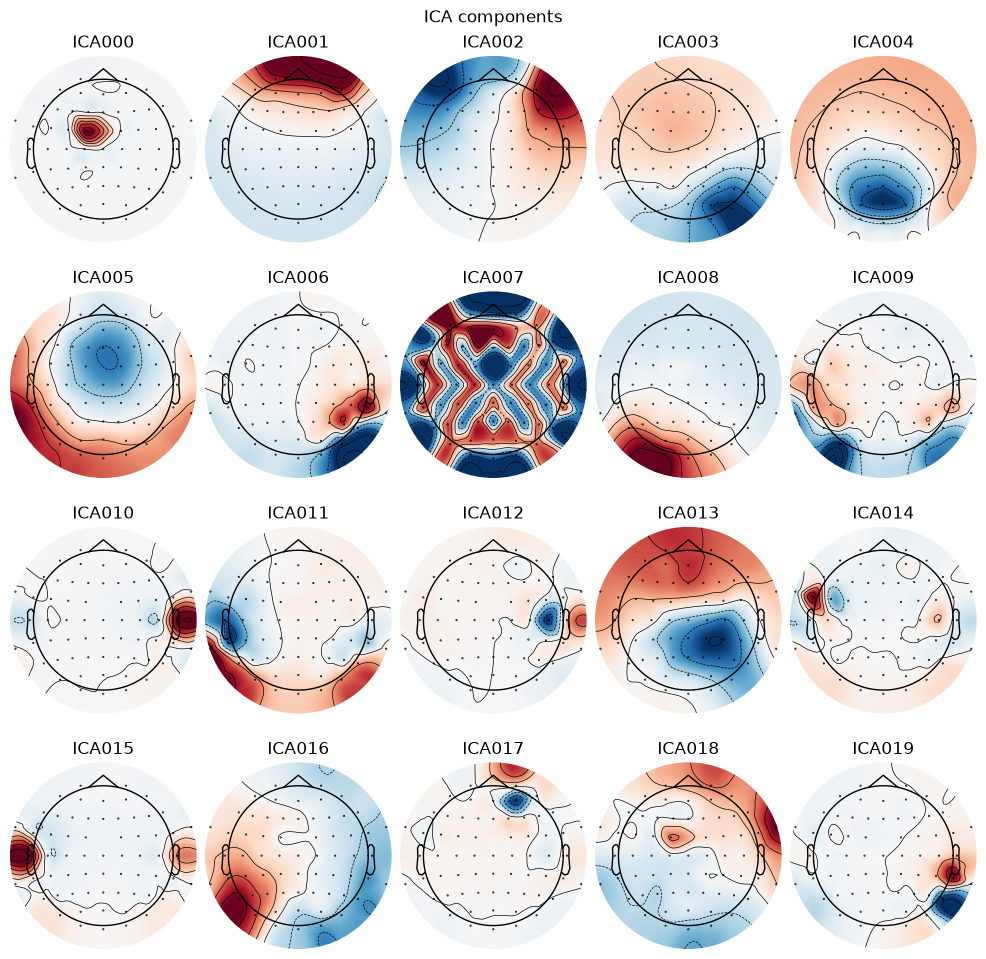

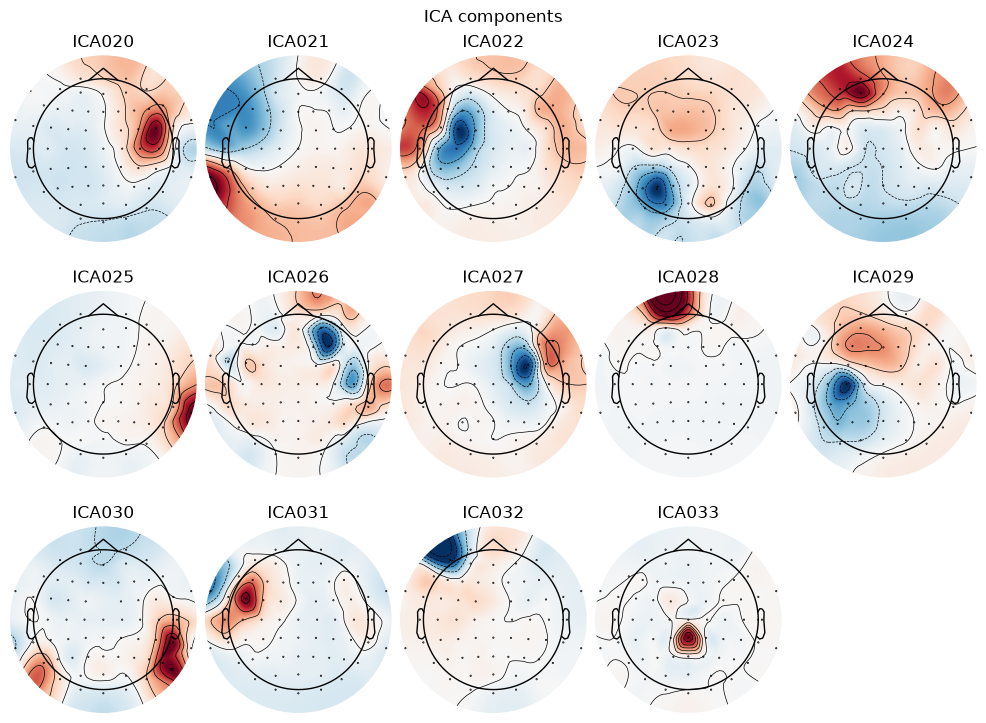

{'y_pred_proba': array([0.741537  , 0.99469686, 0.9996668 , 0.99938613, 0.99993944,
        0.9891156 , 0.6178339 , 0.998346  , 0.7518778 , 0.83095336,
        0.96664596, 0.7491219 , 0.9157449 , 0.9996896 , 0.96338177,
        0.85673   , 0.9515876 , 0.8548521 , 0.29085407, 0.8088585 ,
        0.45722926, 0.6725105 , 0.9510193 , 0.9923705 , 0.4631162 ,
        0.47246796, 0.50747824, 0.6945782 , 0.4833148 , 0.9576512 ,
        0.73867387, 0.9342265 , 0.3893783 , 0.99583983], dtype=float32),
 'labels': ['channel noise',
  'eye blink',
  'eye blink',
  'brain',
  'brain',
  'brain',
  'muscle artifact',
  'line noise',
  'brain',
  'muscle artifact',
  'muscle artifact',
  'muscle artifact',
  'muscle artifact',
  'brain',
  'muscle artifact',
  'muscle artifact',
  'brain',
  'muscle artifact',
  'other',
  'muscle artifact',
  'brain',
  'muscle artifact',
  'muscle artifact',
  'brain',
  'muscle artifact',
  'muscle artifact',
  'other',
  'muscle artifact',
  'eye blink',
  'brain'

In [5]:
participant = 32
cache_dir = "data/filtered-referenced-eeg"
cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"

if os.path.exists(cached_file):
    print(f"Found file {cached_file}")
    raw = mne.io.read_raw_fif(cached_file, preload=True)
    ica = mne.preprocessing.ICA(n_components=0.99, method="fastica", random_state=42)
    ica.fit(raw)
    ica.plot_components()
    ica_labels = label_components(raw, ica, "iclabel")
    display(ica_labels)
else:
    print(f"File - {cached_file} not found!")


In [6]:
display(pd.DataFrame(ica_labels))

,y_pred_proba,labels
0,0.741537,channel noise
1,0.994697,eye blink
2,0.999667,eye blink
3,0.999386,brain
4,0.999939,brain
5,0.989116,brain
6,0.617834,muscle artifact
7,0.998346,line noise
8,0.751878,brain
9,0.830953,muscle artifact


Once we see how many independent components there are, let's plot the properties for each of them for further analysis.

In [7]:
# ica.plot_sources()
# ica.plot_properties(raw, picks=[0, 1, 2, 3, 4, 5, 6])

For each participant remove the artifacts using mne-icalabel

In [ ]:
cache_dir = "data/filtered-referenced-eeg"
target_dir = "data/ica-excluded-eeg"
os.makedirs(target_dir, exist_ok=True)

participants = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
for participant in participants:
    cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"
    target_file = f"{target_dir}/sub-0{participant}-task-eeg_ica-cleaned.fif"
    if os.path.exists(target_file):
        print(f"ICA cleaned file exists for {participant} - {target_file}")
    if os.path.exists(cached_file):
        try:
            print(f"Found file {cached_file}")
            raw = mne.io.read_raw_fif(cached_file, preload=True)
            ica = mne.preprocessing.ICA(n_components=0.99, method="fastica", random_state=42)
            ica.fit(raw)
            ica_labels = label_components(raw, ica, "iclabel")
            excluded_components = []
            for idx, label in enumerate(ica_labels["labels"]):
                if label != "brain":
                    excluded_components.append(idx)
                    print(f"Excluding index {idx} from {participant} because label is {label}")
            print(f"For participant {participant}, we are excluding components {excluded_components}")
            ica.exclude = excluded_components
            eeg_ica_cleaned = ica.apply(raw.copy())
            eeg_ica_cleaned.save(target_file, overwrite=True)
            print(f"@ Saved file {target_file}")
        except Exception as error:
            print(f"Error {error} while trying to apply ICA to participant {participant}")
    else:
        print(f"File - {cached_file} not found!")

[WindowsPath('d:/GradSchool/SFU/Courses/IAT-882/Final Project/cognitive-load-biomarkers/data/ica-excluded-eeg/sub-032-task-eeg-ica-excluded.fif')]

### EEG conclusion

EEG data has 63 rows (channel) per participant and between 7 and 9.6 million recordings per channel

### ECG conclusion

## Now we will explore memory task data

## Next steps
- Rebalance the dataset to include participants from `listen` group
- Analyse scores to see min-max of performance in memory task
- Create correlation matrix of EEG/ECG and memory performance
- Create clusters of cognitive load and memory performance
- I have a few questions on how best to approach, will need to talk to Mehdi and Dr. Karduni